# Pandas Practice 2
Work through each task in order. Try to solve it yourself before looking anything up!

In [1]:
import pandas as pd
import numpy as np


---
## Level 1 — Basics

### Task 1: Create a DataFrame
Create a DataFrame with 5 rows representing books.
Columns: `title`, `author`, `pages`, `genre` (use Fiction, Non-Fiction, or Mystery).
Print the DataFrame.

In [2]:
# Your code here
data = {
    'title':  ["tomorrow","gone with wind","educated","bill gates","no two alike"],   # 5 book titles
    'author': ["Ginny","Kevin","Arthur","Melinda","Judith"],   # 5 authors
    'pages':  [200,300,100,500,600],   # 5 page counts
    'genre':  ["fiction","romance","non-fiction","mystery","acient"],   # 5 genres (Fiction, Non-Fiction, or Mystery)
}

books = pd.DataFrame(data)
books

,title,author,pages,genre
0,tomorrow,Ginny,200,fiction
1,gone with wind,Kevin,300,romance
2,educated,Arthur,100,non-fiction
3,bill gates,Melinda,500,mystery
4,no two alike,Judith,600,acient


### Task 2: Inspect a Dataset
Run the cell below to load a dataset, then use `.head()`, `.info()`, `.describe()`, and `.shape` to explore it.

**Question to answer:** How many rows and columns are there? Which columns have missing values?

In [3]:
# Run this to load a sample dataset
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
titanic = pd.read_csv(url)

# Now explore it — try .head(), .info(), .describe(), .shape below
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# Your exploration here
titanic.info()
titanic.shape
titanic.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Task 3: Select & Filter
Using your `books` DataFrame from Task 1:
1. Select only Fiction books
2. Select only books with more than 300 pages
3. Select just the `title` and `author` columns

In [10]:
# 1. Filter rows where genre == 'Fiction'
fiction = books[books['genre']=='fiction']
print(fiction)

# 2. Filter rows where pages > 300
long_books = books[books['pages'] > 300]
print(long_books)

# 3. Select just title and author columns
title_author =books[['title','author']]
print(title_author)

      title author  pages    genre
0  tomorrow  Ginny    200  fiction
          title   author  pages    genre
3    bill gates  Melinda    500  mystery
4  no two alike   Judith    600   acient
            title   author
0        tomorrow    Ginny
1  gone with wind    Kevin
2        educated   Arthur
3      bill gates  Melinda
4    no two alike   Judith


---
## Level 2 — Transformations

### Task 4: Add a Column
Add a column `long_read` to your `books` DataFrame.
It should be `True` if the book has more than 300 pages, and `False` otherwise.

In [11]:
# Add a 'long_read' column
books['long_read'] = books['pages'] >300
books

,title,author,pages,genre,long_read
0,tomorrow,Ginny,200,fiction,False
1,gone with wind,Kevin,300,romance,False
2,educated,Arthur,100,non-fiction,False
3,bill gates,Melinda,500,mystery,True
4,no two alike,Judith,600,acient,True


### Task 5: Handle Missing Data
A DataFrame with `NaN` values has been created for you.
1. Find which cells are null using `.isnull()`
2. Drop rows with any null values using `.dropna()`
3. Fill null values with the mean of each column using `.fillna()`

In [23]:
# Starter data — don't change this
scores = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol', 'Dave', 'Emma'],
    'math':    [90, np.nan, 78, 85, np.nan],
    'english': [88, 72, np.nan, 90, 95],
    'science': [np.nan, 80, 85, np.nan, 88],
})

# 1. Show which values are null
scores.isnull()

# 2. Drop rows with any null
scores.dropna(axis=1)
# 3. Fill nulls with the mean of each column
scores.fillna(scores.mean(numeric_only=True))

,student,math,english,science
0,Alice,90.000000,88.00,84.333333
1,Bob,84.333333,72.00,80.000000
2,Carol,78.000000,86.25,85.000000
3,Dave,85.000000,90.00,84.333333
4,Emma,84.333333,95.00,88.000000


### Task 6: Sort & Rank
An orders DataFrame has been created for you.
1. Sort by `amount` descending
2. Add a `rank` column (1 = highest amount) using `.rank()`

In [ ]:
# Starter data — don't change this
orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105],
    'customer': ['Alice', 'Bob', 'Carol', 'Dave', 'Emma'],
    'amount':   [250.0, 89.5, 430.0, 175.0, 310.0],
})

# 1. Sort by amount descending
orders.sort_values('amount',ascending=False)

# 2. Add a rank column (1 = highest amount)
orders['rank'] = orders['amount'].rank(ascending=False)
orders

,order_id,customer,amount
2,103,Carol,430.0
4,105,Emma,310.0
0,101,Alice,250.0
3,104,Dave,175.0
1,102,Bob,89.5


---
## Level 3 — Aggregation

### Task 7: GroupBy
Using the `transactions` DataFrame below, find the **average amount spent per category** using `.groupby()`.

In [28]:
# Starter data — don't change this
transactions = pd.DataFrame({
    'category': ['Food', 'Tech', 'Food', 'Clothing', 'Tech', 'Clothing', 'Food'],
    'customer': ['Alice', 'Bob', 'Carol', 'Dave', 'Alice', 'Bob', 'Dave'],
    'amount':   [45, 999, 30, 120, 599, 85, 60],
})

# Average amount per category
avg_by_category = transactions.groupby('category')['amount'].mean()
avg_by_category

category
Clothing    102.5
Food         45.0
Tech        799.0
Name: amount, dtype: float64

### Task 8: Pivot Table
Using the same `transactions` DataFrame, create a pivot table showing the **total amount** for each combination of `category` and `customer`.

In [29]:
# Create a pivot table
pivot = pd.pivot_table(
    transactions,
    values='amount',
    index='category',
    columns='customer',
    aggfunc=sum
)
pivot

/var/folders/3r/5sttq01d46zg8zxyw17j5nbw0000gn/T/ipykernel_42442/2795167284.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot = pd.pivot_table(


customer,Alice,Bob,Carol,Dave
category,,,,
Clothing,NaN,85.0,NaN,120.0
Food,45.0,NaN,30.0,60.0
Tech,599.0,999.0,NaN,NaN


### Task 9: Merge DataFrames
Two DataFrames are provided. Merge them on `book_id` so each row has the title and its rating.

Try `how='inner'`, `how='left'`, and `how='outer'` — what changes?

In [31]:
# Starter data — don't change this
book_info = pd.DataFrame({
    'book_id': [1, 2, 3, 4],
    'title':   ['Dune', '1984', 'Sapiens', 'Educated'],
})

ratings = pd.DataFrame({
    'book_id': [1, 2, 3, 5],   # note: id 4 is missing, id 5 is extra
    'rating':  [4.8, 4.7, 4.5, 4.2],
})

# Merge on book_id
merged = pd.merge(book_info, ratings, on='book_id', how='inner')
merged

,book_id,title,rating
0,1,Dune,4.8
1,2,1984,4.7
2,3,Sapiens,4.5


---
## Level 4 — Real-world

### Task 10: Time Series
1. Create a DataFrame with a daily date range for all of 2025 and a random `temperature` column (use `np.random.uniform(15, 35, ...)` for realistic temps)
2. Set the date as the index
3. Resample to **monthly averages** and plot the result

/var/folders/3r/5sttq01d46zg8zxyw17j5nbw0000gn/T/ipykernel_42442/1742076864.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = weather.resample('M').mean()


<Axes: title={'center': 'Monthly Average Temperature'}, xlabel='date'>

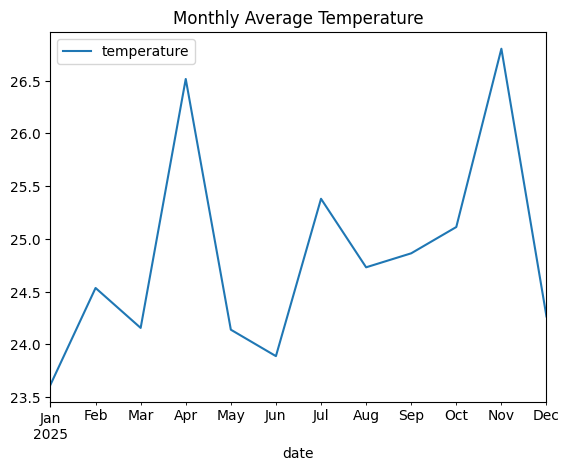

In [32]:
# 1. Create date range for 2025
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')

weather = pd.DataFrame({
    'date':        dates,
    'temperature': np.random.uniform(15, 35, len(dates)),
})

# 2. Set date as index
weather = weather.set_index('date')

# 3. Resample to monthly averages
monthly = weather.resample('M').mean()

# Plot it
monthly.plot(title='Monthly Average Temperature')